In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv('titanic.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [7]:
df.drop(columns=['Cabin'], inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [13]:
df['Sex']=df['Sex'].map({'male':1, 'female':0})

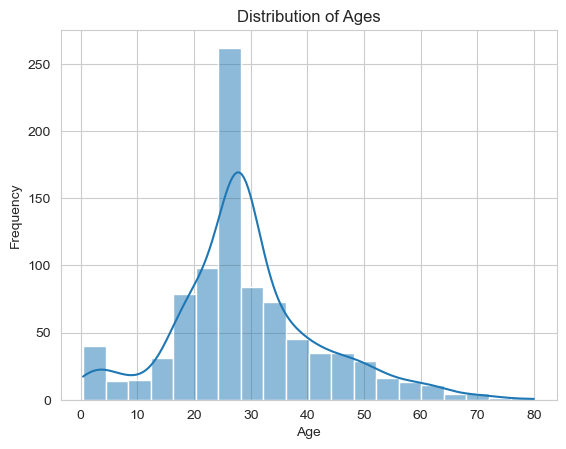

In [15]:
sns.set_style("whitegrid")
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Distribution of Ages")
plt.xlabel("Age")
plt.ylabel('Frequency')
plt.show()

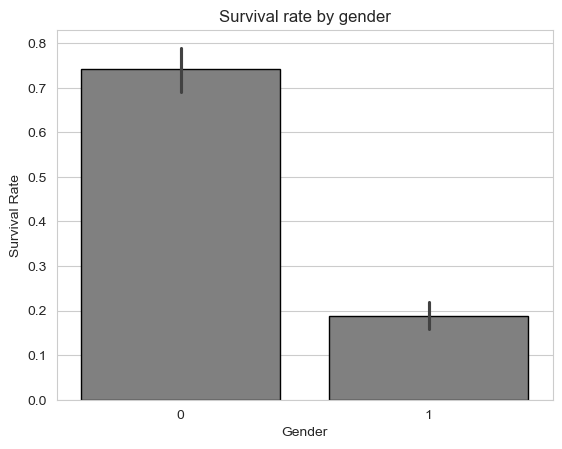

In [31]:
sns.barplot(df, x='Sex' , y='Survived', color='Gray', edgecolor='black')
plt.title("Survival rate by gender")
plt.xlabel("Gender")
plt.ylabel('Survival Rate')
plt.show()


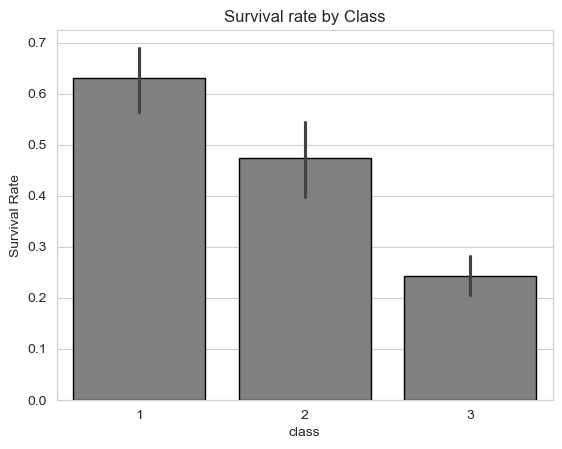

In [29]:
# survival rate by passenger class

sns.barplot(df, x='Pclass' , y='Survived', color='Gray', edgecolor='black')
plt.title("Survival rate by Class")
plt.xlabel("class")
plt.ylabel('Survival Rate')
plt.show()

In [35]:
df['AgeGroup']= pd.cut(df['Age'], bins=[0,10,20,30,40,50,60],
                       labels=['0-10','11-20','21-30','31-40','41-50','51-60'])

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    int64   
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    object  
 11  AgeGroup     869 non-null    category
dtypes: category(1), float64(2), int64(6), object(3)
memory usage: 77.8+ KB


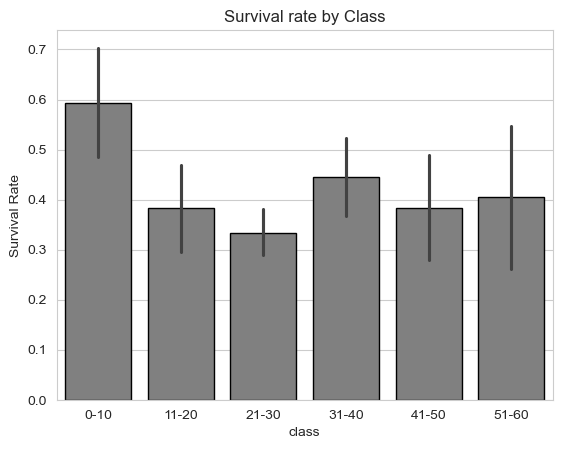

In [38]:
sns.barplot(df, x='AgeGroup' , y='Survived', color='Gray', edgecolor='black')
plt.title("Survival rate by Class")
plt.xlabel("class")
plt.ylabel('Survival Rate')
plt.show()

In [39]:
df['Embarked'] = df['Embarked'].astype('category').cat.codes
df['AgeGroup']= df['AgeGroup'].cat.codes

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    int8   
 11  AgeGroup     891 non-null    int8   
dtypes: float64(2), int64(6), int8(2), object(2)
memory usage: 71.5+ KB


In [43]:
df['FamilySize']=df['SibSp'] + df['Parch'] + 1

In [45]:
fearures =['Pclass','Sex','Age','Fare','Embarked','AgeGroup','FamilySize']

X=df[fearures]
y=df['Survived']

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train ,y_test = train_test_split(X,y, test_size=0.2, random_state= 7)

randomforestmodel = RandomForestClassifier()
randomforestmodel.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

y_pred= randomforestmodel.predict(X_test)
print(accuracy_score(y_pred, y_test))

0.776536312849162
